# Fashion Dataset — EDA & Augmentation
**Workflow:**
1. Setup & load data
2. Basic stats
3. Class distribution & imbalance
4. Multi-label analysis
5. Co-occurrence heatmap
6. Per-image label count distribution
7. Image integrity check
8. Augmentation strategy & preview

## 0. Install dependencies

In [1]:
# Dependencies are listed in requirements.txt.


## 1. Setup & load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

PROJECT_DIR = Path('/Users/iryna/Desktop/ml project')
CSV_PATH = PROJECT_DIR / 'output' / 'dataset.csv'
IMAGE_DIR = PROJECT_DIR / 'output' / 'train_512'
IMG_COL = 'filename'

df = pd.read_csv(CSV_PATH)
df = df.drop(columns=['split'], errors='ignore')
print(f'Shape: {df.shape}')
df.head(3)


Shape: (9386, 25)


,filename,dress,t_shirt,shirt,sweater,hoodie,jacket,coat,blazer,cardigan,...,shoes,sneakers,boots,heels,sandals,bag,hat,scarf,belt,sunglasses
0,0002ec21ddb8477e98b2cbb87ea2e269.jpg,1,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,00048c3a2fb9c29340473c4cfc06424a.jpg,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,00048c3a2fb9c29340473c4cfc06424a_aug_hflip.jpg,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


## 2. Basic stats

In [3]:
label_cols = [c for c in df.columns if c != IMG_COL]
print('='*55)
print(f'  Total rows (images)      : {len(df):,}')
print(f'  Total label columns      : {len(label_cols)}')
print(f'  Label columns            : {label_cols}')
print(f'  Missing values           : {df[label_cols].isnull().sum().sum()}')
print(f'  Unique label values      : {df[label_cols].stack().unique()}')
print('='*55)

no_label = (df[label_cols].sum(axis=1) == 0).sum()
print(f'  Rows with 0 labels       : {no_label} ({no_label/len(df)*100:.1f}%)')

df['_n_labels'] = df[label_cols].sum(axis=1)
print(f'  Avg labels per image     : {df['_n_labels'].mean():.2f}')
print(f'  Max labels per image     : {df['_n_labels'].max()}')


  Total rows (images)      : 9,386
  Total label columns      : 24
  Label columns            : ['dress', 't_shirt', 'shirt', 'sweater', 'hoodie', 'jacket', 'coat', 'blazer', 'cardigan', 'trousers', 'jeans', 'shorts', 'skirt', 'leggings', 'shoes', 'sneakers', 'boots', 'heels', 'sandals', 'bag', 'hat', 'scarf', 'belt', 'sunglasses']
  Missing values           : 0
  Unique label values      : [1 0]
  Rows with 0 labels       : 131 (1.4%)
  Avg labels per image     : 2.77
  Max labels per image     : 9


## 3. Class distribution & imbalance

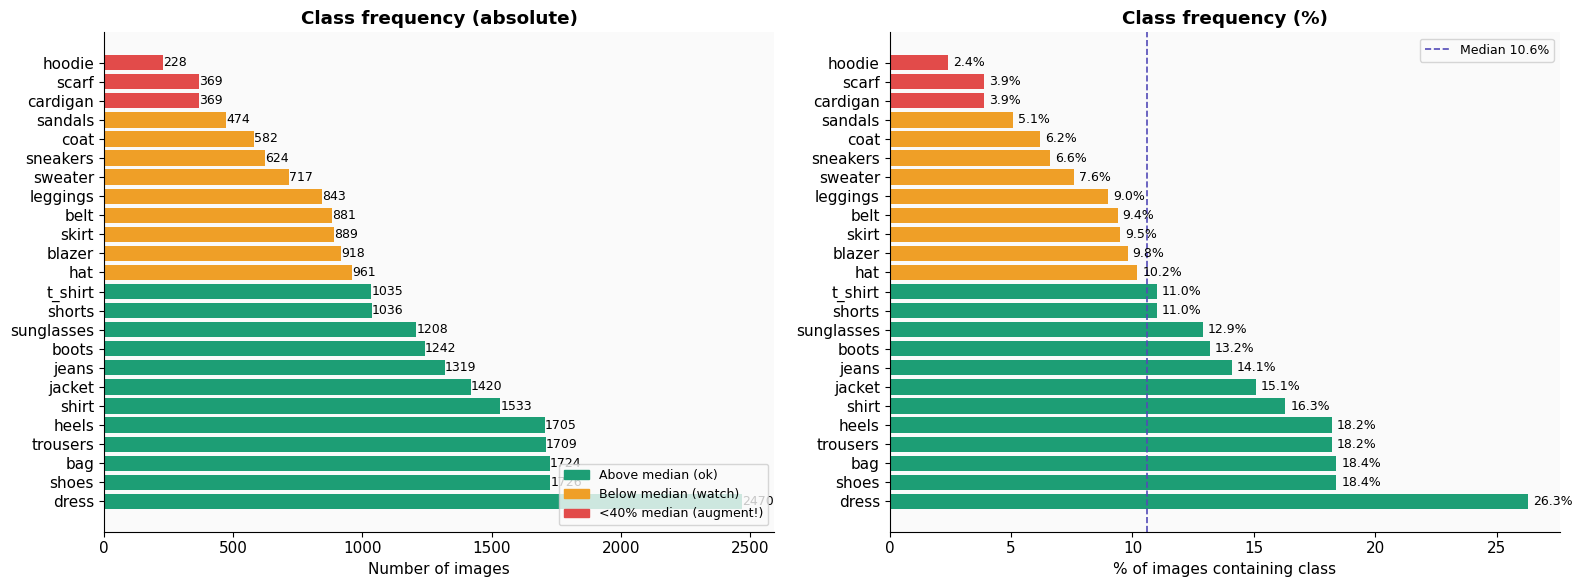

Saved → eda_class_distribution.png


In [4]:
class_counts = df[label_cols].sum().sort_values(ascending=False)
class_pct    = (class_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Absolute counts ---
colors = ['#E24B4A' if v < class_counts.median()*0.4
          else '#EF9F27' if v < class_counts.median()
          else '#1D9E75'
          for v in class_counts.values]

bars = axes[0].barh(class_counts.index, class_counts.values, color=colors, edgecolor='none')
axes[0].set_xlabel('Number of images')
axes[0].set_title('Class frequency (absolute)', fontweight='bold')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#1D9E75', label='Above median (ok)'),
    mpatches.Patch(color='#EF9F27', label='Below median (watch)'),
    mpatches.Patch(color='#E24B4A', label='<40% median (augment!)')
]
axes[0].legend(handles=patches, fontsize=9, loc='lower right')

# --- Percentage ---
axes[1].barh(class_pct.index, class_pct.values, color=colors, edgecolor='none')
axes[1].axvline(x=class_pct.median(), color='#534AB7', linestyle='--', linewidth=1.2, label=f'Median {class_pct.median():.1f}%')
axes[1].set_xlabel('% of images containing class')
axes[1].set_title('Class frequency (%)', fontweight='bold')
axes[1].legend(fontsize=9)
for i, (idx, val) in enumerate(class_pct.items()):
    axes[1].text(val + 0.2, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eda_class_distribution.png')

In [5]:
# Imbalance ratio table
summary = pd.DataFrame({
    'count': class_counts,
    'pct':   class_pct,
    'imbalance_ratio': (class_counts.max() / class_counts).round(1)
})
summary['severity'] = pd.cut(
    summary['imbalance_ratio'],
    bins=[0, 2, 5, 10, np.inf],
    labels=['ok', 'mild', 'severe', 'critical']
)
print(summary.to_string())

            count   pct  imbalance_ratio  severity
dress        2470  26.3              1.0        ok
shoes        1726  18.4              1.4        ok
bag          1724  18.4              1.4        ok
trousers     1709  18.2              1.4        ok
heels        1705  18.2              1.4        ok
shirt        1533  16.3              1.6        ok
jacket       1420  15.1              1.7        ok
jeans        1319  14.1              1.9        ok
boots        1242  13.2              2.0        ok
sunglasses   1208  12.9              2.0        ok
shorts       1036  11.0              2.4      mild
t_shirt      1035  11.0              2.4      mild
hat           961  10.2              2.6      mild
blazer        918   9.8              2.7      mild
skirt         889   9.5              2.8      mild
belt          881   9.4              2.8      mild
leggings      843   9.0              2.9      mild
sweater       717   7.6              3.4      mild
sneakers      624   6.6        

## 4. Multi-label analysis

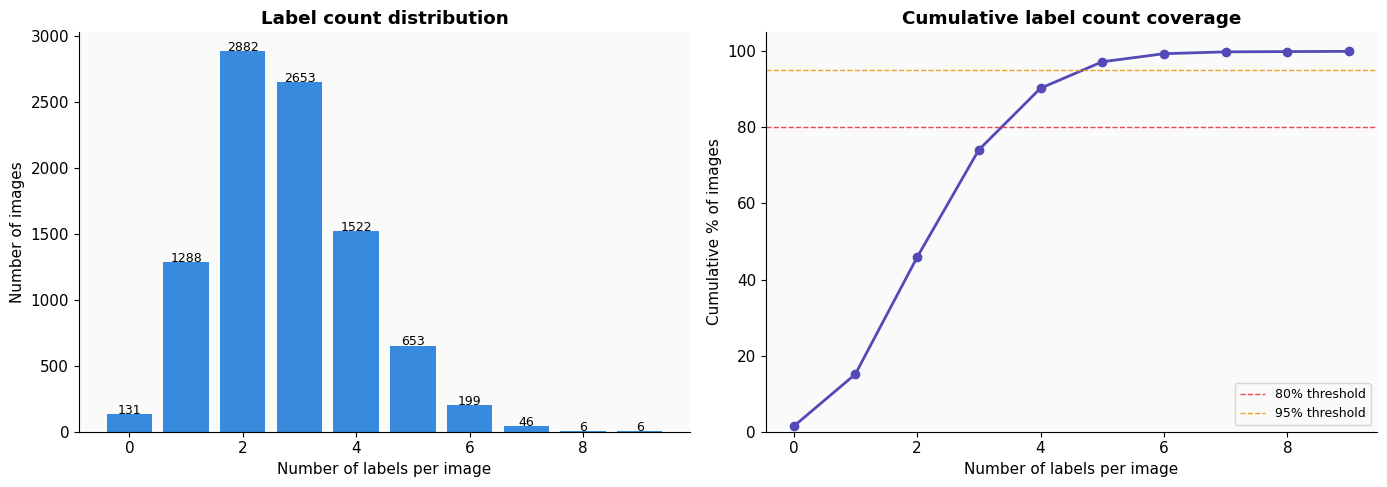

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Distribution of label count per image ---
label_count_dist = df['_n_labels'].value_counts().sort_index()
axes[0].bar(label_count_dist.index, label_count_dist.values, color='#378ADD', edgecolor='none')
axes[0].set_xlabel('Number of labels per image')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Label count distribution', fontweight='bold')
for x, y in zip(label_count_dist.index, label_count_dist.values):
    axes[0].text(x, y + 0.3, str(y), ha='center', fontsize=9)

# --- Cumulative % ---
cum = label_count_dist.cumsum() / label_count_dist.sum() * 100
axes[1].plot(cum.index, cum.values, marker='o', color='#534AB7', linewidth=2)
axes[1].axhline(y=80, color='#E24B4A', linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(y=95, color='#EF9F27', linestyle='--', linewidth=1, label='95% threshold')
axes[1].set_xlabel('Number of labels per image')
axes[1].set_ylabel('Cumulative % of images')
axes[1].set_title('Cumulative label count coverage', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('eda_label_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Images per class — are there duplicates / images counted multiple times?
imgs_per_class = df.groupby(IMG_COL)['_n_labels'].sum()
print('Images with most label assignments (potential duplicates to inspect):')
print(imgs_per_class.sort_values(ascending=False).head(15).to_string())

Images with most label assignments (potential duplicates to inspect):
filename
79081b06b556c02d04bc8706bfc0ce3b_aug_vflip.jpg    9
79081b06b556c02d04bc8706bfc0ce3b_aug_hflip.jpg    9
17e7ce0708f2de574e412a6d01e6035f_aug_vflip.jpg    9
17e7ce0708f2de574e412a6d01e6035f_aug_hflip.jpg    9
17e7ce0708f2de574e412a6d01e6035f.jpg              9
79081b06b556c02d04bc8706bfc0ce3b.jpg              9
025eea6cc05fd843b617b9ef44dc55fb_aug_hflip.jpg    8
9b1933bc99038ec345114973f46de9bf.jpg              8
9b1933bc99038ec345114973f46de9bf_aug_hflip.jpg    8
025eea6cc05fd843b617b9ef44dc55fb_aug_vflip.jpg    8
9b1933bc99038ec345114973f46de9bf_aug_vflip.jpg    8
025eea6cc05fd843b617b9ef44dc55fb.jpg              8
6129970e06c927eb7e3f6587c3173af8.jpg              7
416df8f3846e380de31ec1610a18ad0c_aug_vflip.jpg    7
96ac2a691f77f46b377a24da856e6f39.jpg              7


## 5. Co-occurrence heatmap

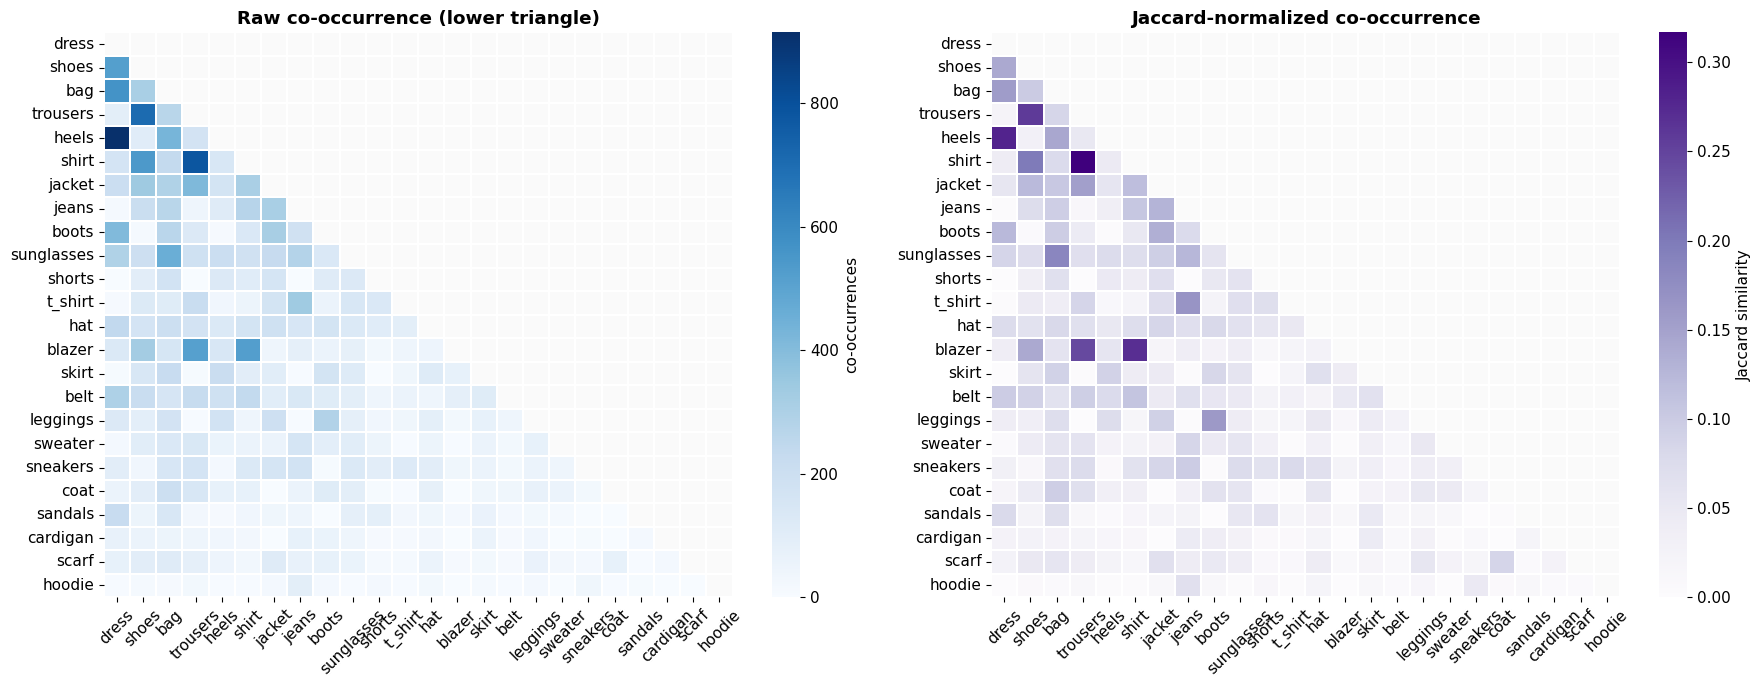


Top 15 co-occurring pairs (by Jaccard):
 class_a    class_b  count  jaccard
trousers      shirt    780    0.317
   dress      heels    915    0.281
   shirt     blazer    522    0.271
   shoes   trousers    707    0.259
trousers     blazer    516    0.244
   shoes      shirt    543    0.200
     bag sunglasses    459    0.186
   jeans    t_shirt    336    0.167
   boots   leggings    288    0.160
   dress        bag    568    0.157
trousers     jacket    414    0.152
     bag      heels    431    0.144
   shoes     blazer    327    0.141
   dress      shoes    519    0.141
  jacket      boots    315    0.134


In [8]:
# Only classes that appear at least once
active_cols = class_counts[class_counts > 0].index.tolist()
sub = df[active_cols].astype(int)

co = sub.T.dot(sub)          # raw co-occurrence
diag = np.diag(co)           # per-class count

# Jaccard-normalized: co(A,B) / (|A| + |B| - co(A,B))
jaccard = pd.DataFrame(co.values.copy().astype(float), index=active_cols, columns=active_cols)
for i in range(len(active_cols)):
    for j in range(len(active_cols)):
        union = diag[i] + diag[j] - co.iloc[i, j]
        jaccard.iloc[i, j] = co.iloc[i, j] / union if union > 0 else 0

# Hide diagonal
for i in range(len(active_cols)):
    jaccard.iloc[i, i] = 0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.zeros_like(co, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(co, ax=axes[0], cmap='Blues', mask=mask,
            xticklabels=active_cols, yticklabels=active_cols,
            linewidths=0.3, linecolor='white', annot=len(active_cols)<=15,
            fmt='d', cbar_kws={'label': 'co-occurrences'})
axes[0].set_title('Raw co-occurrence (lower triangle)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

mask2 = np.zeros_like(jaccard, dtype=bool)
mask2[np.triu_indices_from(mask2)] = True

sns.heatmap(jaccard, ax=axes[1], cmap='Purples', mask=mask2,
            xticklabels=active_cols, yticklabels=active_cols,
            linewidths=0.3, linecolor='white', annot=len(active_cols)<=15,
            fmt='.2f', cbar_kws={'label': 'Jaccard similarity'})
axes[1].set_title('Jaccard-normalized co-occurrence', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

# Top pairs
pairs = []
for i in range(len(active_cols)):
    for j in range(i+1, len(active_cols)):
        pairs.append((active_cols[i], active_cols[j],
                      int(co.iloc[i,j]), round(float(jaccard.iloc[i,j]), 3)))

pairs_df = pd.DataFrame(pairs, columns=['class_a','class_b','count','jaccard'])
print('\nTop 15 co-occurring pairs (by Jaccard):')
print(pairs_df.sort_values('jaccard', ascending=False).head(15).to_string(index=False))

## 6. Duplicate / imbalance check — how many images per unique path?

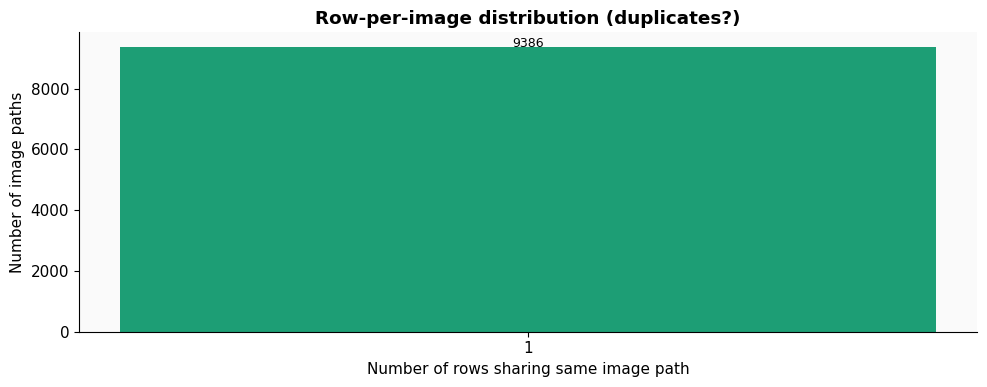

Unique image paths : 9,386
Total rows         : 9,386
Images with >1 row : 0 (0.0% of unique paths)
Max rows per image : 1

Top 10 most duplicated images:
filename
0002ec21ddb8477e98b2cbb87ea2e269.jpg              1
00048c3a2fb9c29340473c4cfc06424a.jpg              1
00048c3a2fb9c29340473c4cfc06424a_aug_hflip.jpg    1
00048c3a2fb9c29340473c4cfc06424a_aug_vflip.jpg    1
000b3a87508b0fa185fbd53ecbe2e4c6.jpg              1
00211c06b1fe730097dde122cd4d3f8c.jpg              1
00211c06b1fe730097dde122cd4d3f8c_aug_hflip.jpg    1
00211c06b1fe730097dde122cd4d3f8c_aug_vflip.jpg    1
00375f11809c48821f56051b55b8e8dc_aug_vflip.jpg    1
0038d87bdf966bc82cf430f924c1d8c6.jpg              1


In [9]:
path_counts = df[IMG_COL].value_counts()
unique_paths = len(path_counts)
duplicate_paths = int((path_counts > 1).sum())

fig, ax = plt.subplots(figsize=(10, 4))
vc = path_counts.value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='#1D9E75', edgecolor='none')
ax.set_xlabel('Number of rows sharing same image path')
ax.set_ylabel('Number of image paths')
ax.set_title('Row-per-image distribution (duplicates?)', fontweight='bold')
for x, y in zip(vc.index.astype(str), vc.values):
    ax.text(x, y + 0.3, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unique image paths : {unique_paths:,}')
print(f'Total rows         : {len(df):,}')
print(f'Images with >1 row : {duplicate_paths} ({duplicate_paths/unique_paths*100:.1f}% of unique paths)')
print(f'Max rows per image : {path_counts.max()}')
print('\nTop 10 most duplicated images:')
print(path_counts.head(10).to_string())


## 7. Image file integrity check

In [10]:
def check_images(df, img_col, image_dir, sample_n=None):
    paths = df[img_col].unique()
    if sample_n:
        paths = np.random.choice(paths, min(sample_n, len(paths)), replace=False)

    results = []
    for p in tqdm(paths, desc='Checking images'):
        full = Path(image_dir) / p
        rec = {'path': str(p), 'exists': full.exists(),
               'readable': False, 'w': None, 'h': None, 'mode': None, 'error': None}
        if rec['exists']:
            try:
                img = Image.open(full)
                img.verify()
                img = Image.open(full)
                rec['readable'] = True
                rec['w'], rec['h'] = img.size
                rec['mode'] = img.mode
            except Exception as e:
                rec['error'] = str(e)
        results.append(rec)

    return pd.DataFrame(results)

img_report = check_images(df, IMG_COL, IMAGE_DIR, sample_n=200)

print(f'Checked : {len(img_report)} images')
print(f'Missing : {(~img_report['exists']).sum()}')
print(f'Corrupt : {(img_report['exists'] & ~img_report['readable']).sum()}')
print(f'OK      : {img_report['readable'].sum()}')

bad = img_report[~img_report['readable']]
if len(bad):
    print('\nProblematic files:')
    print(bad[['path','exists','error']].to_string(index=False))


Checking images:   0%|          | 0/200 [00:00<?, ?it/s]

Checking images: 100%|██████████| 200/200 [00:00<00:00, 3155.33it/s]

Checked : 200 images
Missing : 0
Corrupt : 0
OK      : 200


In [11]:
print('Dir exists:', IMAGE_DIR.exists())
files = list(IMAGE_DIR.glob('*.jpg'))[:3]
print('Found files:', files)

if files:
    img = Image.open(files[0])
    print('Size:', img.size)
    print('Mode:', img.mode)


Dir exists: True


Found files: [PosixPath('/Users/iryna/Desktop/ml project/output/train_512/8bf9ef13bda84c849519a7cc18da4199.jpg'), PosixPath('/Users/iryna/Desktop/ml project/output/train_512/03ebb3b4c195415126834c89f8da55b5.jpg'), PosixPath('/Users/iryna/Desktop/ml project/output/train_512/3537cd7b51f569e2c3d69fa31964980b_aug_vflip.jpg')]
Size: (512, 512)
Mode: RGB


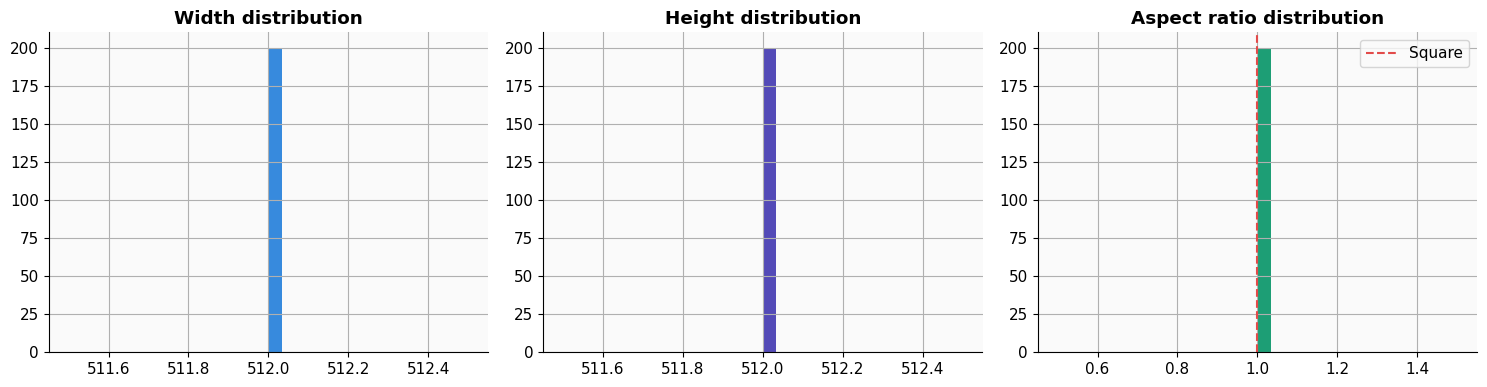

           w      h  aspect  megapx
count  200.0  200.0   200.0   200.0
mean   512.0  512.0     1.0     0.3
std      0.0    0.0     0.0     0.0
min    512.0  512.0     1.0     0.3
25%    512.0  512.0     1.0     0.3
50%    512.0  512.0     1.0     0.3
75%    512.0  512.0     1.0     0.3
max    512.0  512.0     1.0     0.3


In [12]:
# Image resolution distribution
ok = img_report[img_report['readable']].copy()
ok['aspect'] = (ok['w'] / ok['h']).round(2)
ok['megapx']  = (ok['w'] * ok['h'] / 1e6).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ok['w'].hist(bins=30, ax=axes[0], color='#378ADD', edgecolor='none')
axes[0].set_title('Width distribution', fontweight='bold')

ok['h'].hist(bins=30, ax=axes[1], color='#534AB7', edgecolor='none')
axes[1].set_title('Height distribution', fontweight='bold')

ok['aspect'].hist(bins=30, ax=axes[2], color='#1D9E75', edgecolor='none')
axes[2].axvline(x=1.0, color='#E24B4A', linestyle='--', label='Square')
axes[2].set_title('Aspect ratio distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()

print(ok[['w','h','aspect','megapx']].describe().round(1))

## 8. Augmentation — strategy & visual preview

In [13]:
import albumentations as A
import cv2

LIGHT_AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
], p=1.0)

MEDIUM_AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.6),
    A.RandomBrightnessContrast(0.3, 0.3, p=0.5),
    A.HueSaturationValue(15, 30, 15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=0.5),
], p=1.0)

HEAVY_AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.OneOf([
        A.RandomBrightnessContrast(0.4, 0.4),
        A.RandomGamma(gamma_limit=(70, 130)),
        A.CLAHE(clip_limit=4.0),
    ], p=0.6),
    A.HueSaturationValue(20, 40, 20, p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MotionBlur(blur_limit=7),
        A.MedianBlur(blur_limit=5),
    ], p=0.3),
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 32), hole_width_range=(8, 32), fill=0, p=0.3),
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=0.5),
], p=1.0)

PIPELINES = {'light': LIGHT_AUG, 'medium': MEDIUM_AUG, 'heavy': HEAVY_AUG}
print('Augmentation pipelines defined:', list(PIPELINES.keys()))

Augmentation pipelines defined: ['light', 'medium', 'heavy']


Previewing augmentations on: /Users/iryna/Desktop/ml project/output/train_512/0002ec21ddb8477e98b2cbb87ea2e269.jpg


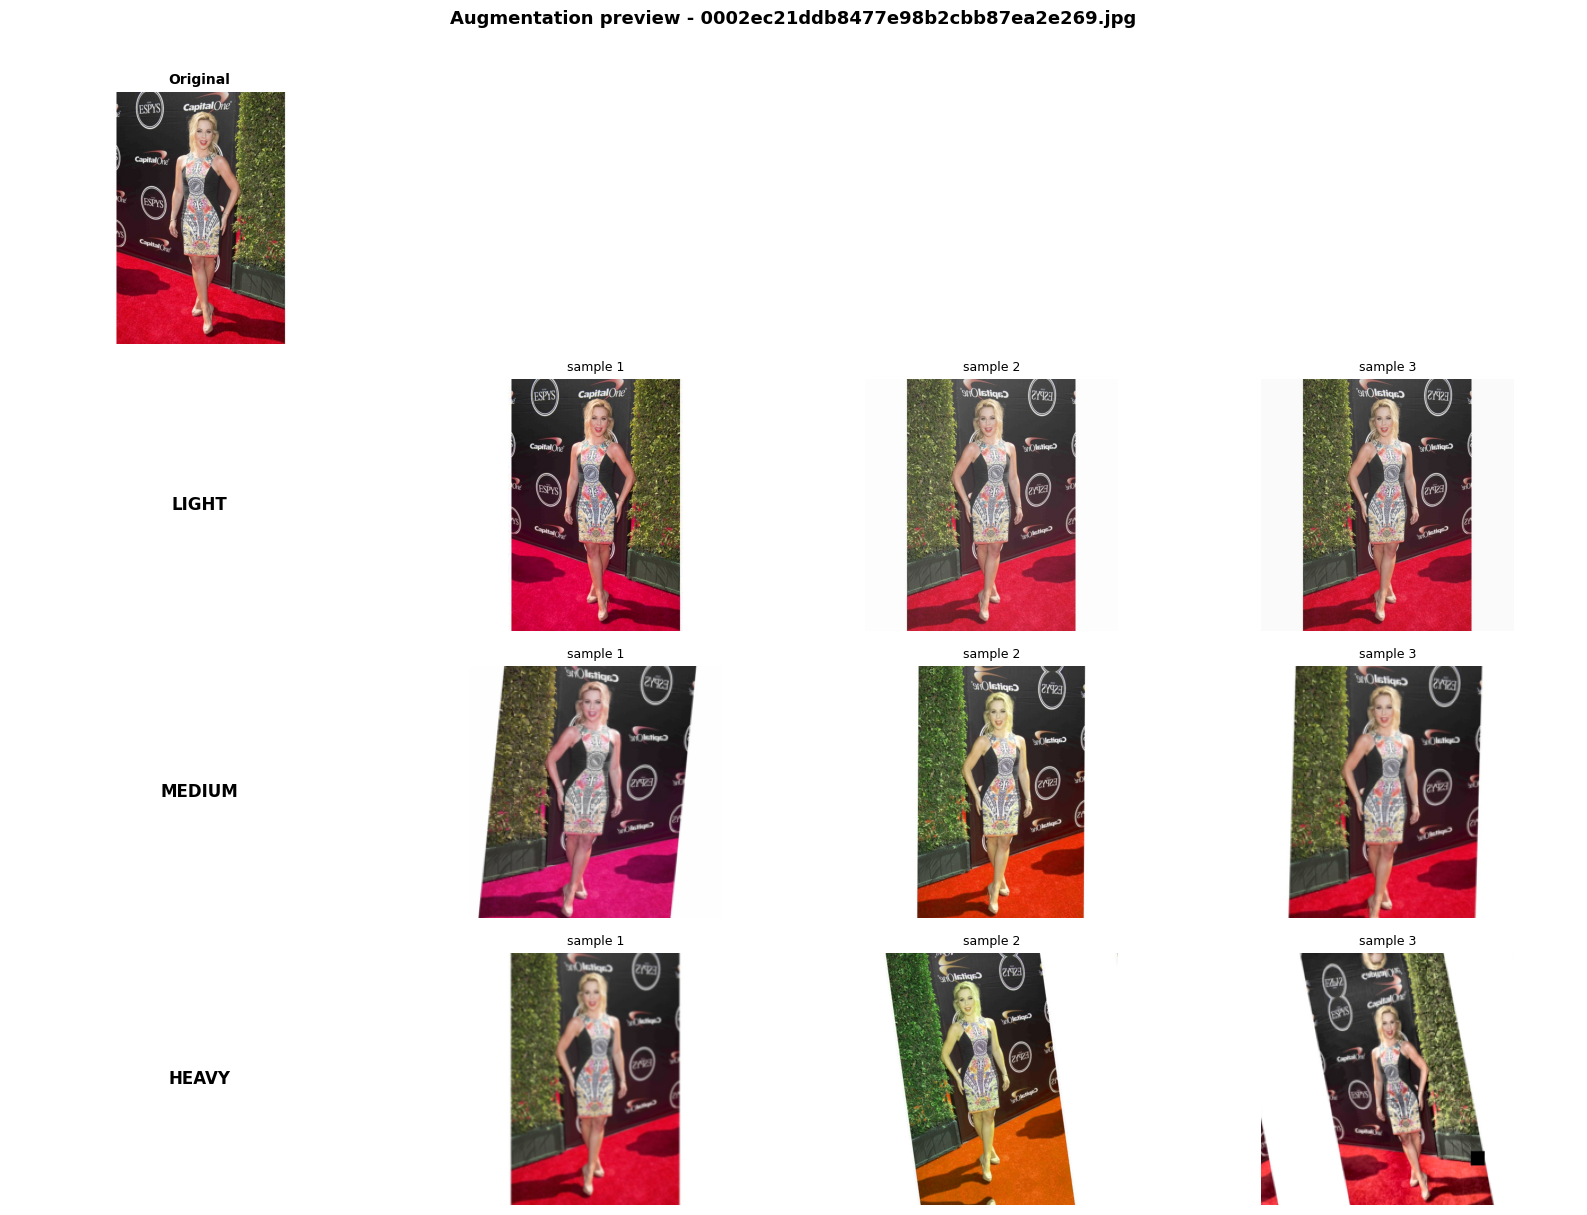

In [14]:
def load_image_rgb(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f'Cannot read: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_augmentation_grid(image_path, n_per_pipeline=3, figsize=(16, 12)):
    img = load_image_rgb(image_path)
    rows = 1 + len(PIPELINES)
    cols = max(n_per_pipeline, 1) + 1
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original', fontweight='bold', fontsize=10)
    axes[0, 0].axis('off')
    for j in range(1, cols):
        axes[0, j].axis('off')

    for row_idx, (name, pipeline) in enumerate(PIPELINES.items(), start=1):
        axes[row_idx, 0].text(0.5, 0.5, name.upper(), ha='center', va='center',
                              fontsize=12, fontweight='bold',
                              transform=axes[row_idx, 0].transAxes)
        axes[row_idx, 0].axis('off')
        for j in range(1, cols):
            aug_img = pipeline(image=img)['image']
            axes[row_idx, j].imshow(aug_img)
            axes[row_idx, j].set_title(f'sample {j}', fontsize=9)
            axes[row_idx, j].axis('off')

    plt.suptitle(f'Augmentation preview - {Path(image_path).name}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_augmentation_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

sample_path = Path(IMAGE_DIR) / df[IMG_COL].iloc[0]
print(f'Previewing augmentations on: {sample_path}')
show_augmentation_grid(sample_path, n_per_pipeline=3)

## 9. Augmentation plan — per-class targets

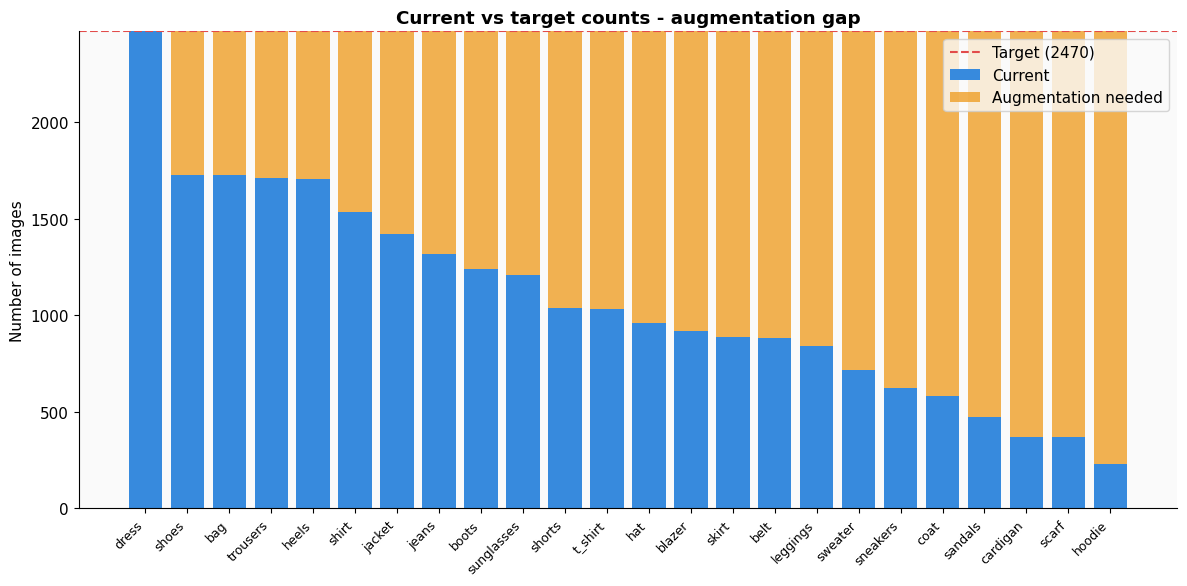

            current  target  needed       strategy
dress          2470    2470       0  no aug needed
shoes          1726    2470     744      LIGHT aug
bag            1724    2470     746      LIGHT aug
trousers       1709    2470     761      LIGHT aug
heels          1705    2470     765      LIGHT aug
shirt          1533    2470     937      LIGHT aug
jacket         1420    2470    1050      LIGHT aug
jeans          1319    2470    1151      LIGHT aug
boots          1242    2470    1228      LIGHT aug
sunglasses     1208    2470    1262      LIGHT aug
shorts         1036    2470    1434      LIGHT aug
t_shirt        1035    2470    1435      LIGHT aug
hat             961    2470    1509     MEDIUM aug
blazer          918    2470    1552     MEDIUM aug
skirt           889    2470    1581     MEDIUM aug
belt            881    2470    1589     MEDIUM aug
leggings        843    2470    1627     MEDIUM aug
sweater         717    2470    1753     MEDIUM aug
sneakers        624    2470    

In [15]:
TARGET = max(class_counts.max(), 200)

aug_plan = pd.DataFrame({
    'current': class_counts,
    'target':  TARGET,
    'needed':  np.maximum(TARGET - class_counts, 0),
    'strategy': pd.cut(
        class_counts,
        bins=[0, TARGET*0.1, TARGET*0.4, TARGET*0.8, np.inf],
        labels=['HEAVY aug', 'MEDIUM aug', 'LIGHT aug', 'no aug needed']
    )
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(aug_plan))
ax.bar(x, aug_plan['current'], label='Current', color='#378ADD', edgecolor='none')
ax.bar(x, aug_plan['needed'], bottom=aug_plan['current'],
       label='Augmentation needed', color='#EF9F27', edgecolor='none', alpha=0.8)
ax.axhline(y=TARGET, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Target ({TARGET})')
ax.set_xticks(x)
ax.set_xticklabels(aug_plan.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of images')
ax.set_title('Current vs target counts - augmentation gap', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_augmentation_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print(aug_plan.to_string())

## 10. Save augmented dataset (per-class oversampling)

In [16]:
import shutil

def augment_and_save(
    df: pd.DataFrame,
    label_cols: list,
    img_col: str,
    image_dir: str,
    output_dir: str,
    target_per_class: int = 200,
    pipelines: dict = PIPELINES,
    dry_run: bool = True,
):
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    if not dry_run:
        for row in tqdm(df.itertuples(), total=len(df), desc='Copying originals'):
            src = Path(image_dir) / getattr(row, img_col)
            dst = out_path / getattr(row, img_col)
            dst.parent.mkdir(parents=True, exist_ok=True)
            if src.exists():
                shutil.copy2(src, dst)

    new_rows = []
    class_counts = df[label_cols].sum()

    for cls in label_cols:
        count = int(class_counts[cls])
        if count >= target_per_class:
            continue

        needed = target_per_class - count
        ratio  = count / target_per_class
        pipeline_name = 'heavy' if ratio < 0.1 else 'medium' if ratio < 0.4 else 'light'
        pipeline = pipelines[pipeline_name]

        cls_rows = df[df[cls] == 1]
        if len(cls_rows) == 0:
            print(f'  [{cls}] No images found, skipping.')
            continue

        print(f'  [{cls}] count={count}, need {needed} more - {pipeline_name} aug')

        for i in range(needed):
            row = cls_rows.sample(1).iloc[0]
            src_path = Path(image_dir) / row[img_col]

            stem = Path(row[img_col]).stem
            ext  = Path(row[img_col]).suffix
            new_name = f'aug_{cls}_{i:04d}_{stem}{ext}'
            new_rel  = str(Path(row[img_col]).parent / new_name)

            if not dry_run and src_path.exists():
                img = load_image_rgb(src_path)
                aug = pipeline(image=img)['image']
                dst = out_path / new_rel
                dst.parent.mkdir(parents=True, exist_ok=True)
                cv2.imwrite(str(dst), cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))

            new_row = row.copy()
            new_row[img_col] = new_rel
            new_rows.append(new_row)

    aug_df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
    return aug_df

aug_df = augment_and_save(
    df.drop(columns=['_n_labels']),
    label_cols=label_cols,
    img_col=IMG_COL,
    image_dir=IMAGE_DIR,
    output_dir='train_augmented/',
    target_per_class=TARGET,
    dry_run=True
)

print(f'\nOriginal rows  : {len(df):,}')
print(f'Augmented rows : {len(aug_df):,}')
print(f'New rows added : {len(aug_df) - len(df):,}')

  [t_shirt] count=1035, need 1435 more - light aug


  [shirt] count=1533, need 937 more - light aug


  [sweater] count=717, need 1753 more - medium aug


  [hoodie] count=228, need 2242 more - heavy aug


  [jacket] count=1420, need 1050 more - light aug


...

  [bag] count=1724, need 746 more - light aug
  [hat] count=961, need 1509 more - medium aug


  [scarf] count=369, need 2101 more - medium aug


  [belt] count=881, need 1589 more - medium aug


  [sunglasses] count=1208, need 1262 more - light aug



Original rows  : 9,386
Augmented rows : 42,684
New rows added : 33,298


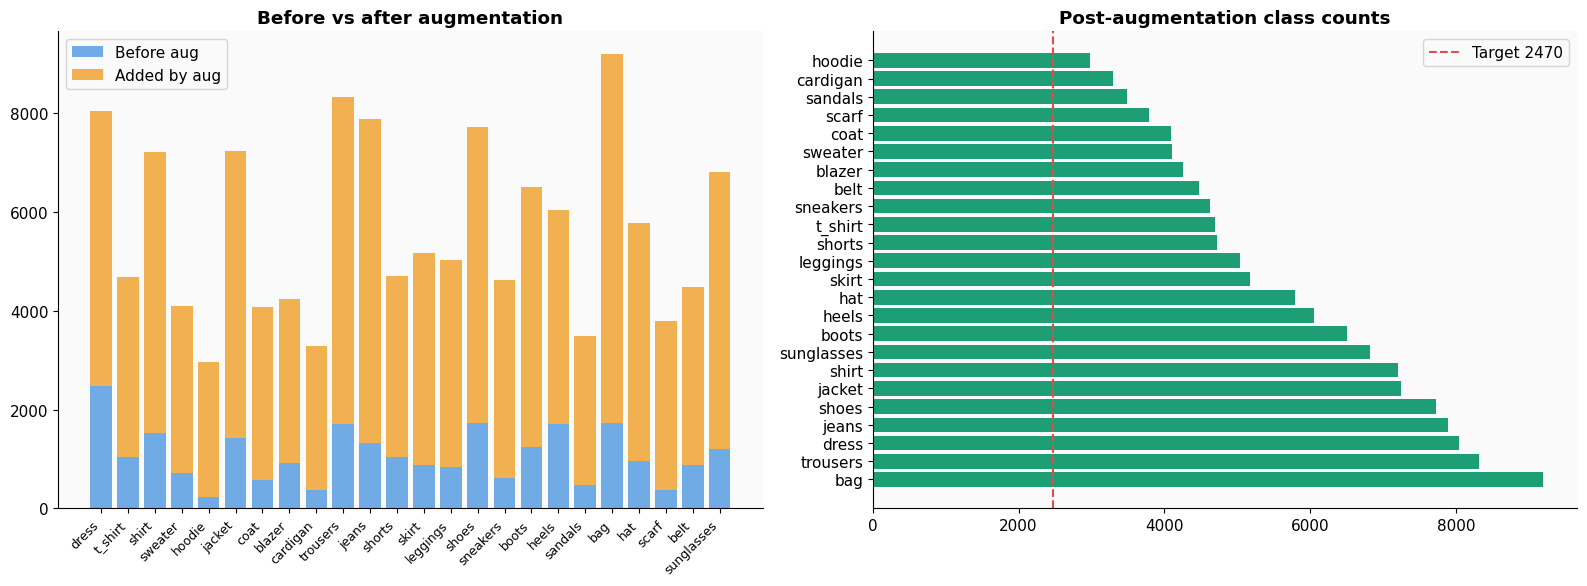

Saved train_labels_augmented.csv


In [17]:
aug_counts = aug_df[label_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(label_cols))
axes[0].bar(x, class_counts[label_cols], label='Before aug', color='#378ADD', alpha=0.7, edgecolor='none')
axes[0].bar(x, aug_counts[label_cols] - class_counts[label_cols], bottom=class_counts[label_cols],
            label='Added by aug', color='#EF9F27', alpha=0.8, edgecolor='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels(label_cols, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Before vs after augmentation', fontweight='bold')
axes[0].legend()

axes[1].barh(aug_counts.index, aug_counts.values, color='#1D9E75', edgecolor='none')
axes[1].axvline(x=TARGET, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Target {TARGET}')
axes[1].set_title('Post-augmentation class counts', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_post_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

aug_df.to_csv('train_labels_augmented.csv', index=False)
print('Saved train_labels_augmented.csv')

## Summary

| Step | Output file |
|------|-------------|
| Class distribution | `eda_class_distribution.png` |
| Label count dist | `eda_label_counts.png` |
| Co-occurrence | `eda_cooccurrence.png` |
| Duplicates | `eda_duplicates.png` |
| Resolution analysis | `eda_resolutions.png` |
| Augmentation preview | `eda_augmentation_preview.png` |
| Augmentation plan | `eda_augmentation_plan.png` |
| Post-aug check | `eda_post_augmentation.png` |
| Augmented CSV | `train_labels_augmented.csv` |

**Next step:** Run `dynamic_schema_builder.py` to add dynamic column detection at inference time.